In [18]:
import os
# from netCDF4 import Dataset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
import pandas as pd
import datetime
from mpl_toolkits.mplot3d import Axes3D, axes3d
import time

import xarray as xr
import netCDF4 as nc
from scipy import signal, integrate

import plt_helper

plt.style.use('latex_default.mplstyle')

In [32]:
thlev=np.exp(4+0.03*np.arange(40,100,1))
thlev

array([ 181.27224188,  186.79280352,  192.4814913 ,  198.34342541,
        204.38388199,  210.60829787,  217.02227542,  223.63158768,
        230.44218346,  237.46019276,  244.69193226,  252.14391102,
        259.82283632,  267.73561971,  275.88938323,  284.29146582,
        292.94942992,  301.87106828,  311.06441098,  320.53773265,
        330.29955991,  340.35867907,  350.72414402,  361.40528437,
        372.41171388,  383.75333906,  395.44036816,  407.48332027,
        419.89303489,  432.68068157,  445.85777008,  459.43616068,
        473.42807483,  487.84610621,  502.70323202,  518.01282467,
        533.78866383,  550.04494881,  566.79631138,  584.05782889,
        601.84503787,  620.17394801,  639.06105657,  658.52336322,
        678.57838534,  699.24417382,  720.53932925,  742.48301872,
        765.09499302,  788.39560446,  812.40582517,  837.14726595,
        862.64219579,  888.91356183,  915.98501008,  943.88090667,
        972.62635979, 1002.24724229, 1032.77021496, 1064.22275

In [20]:
def truncate_first_time_index(fpath: str):
    fpath_temp = fpath + "_temp"
    with nc.Dataset(fpath, mode="r") as src, nc.Dataset(fpath_temp, mode="w", format="NETCDF4") as dst:
        for name, dim in src.dimensions.items():
            if name == "time":
                dst.createDimension(name, None)
            else:
                dst.createDimension(name, len(dim))

        for name, var in src.variables.items():
            new_var = dst.createVariable(name, var.datatype, var.dimensions)
            new_var.setncatts({k: var.getncattr(k) for k in var.ncattrs()})

            if var.dimensions and var.dimensions[0] == "time":
                new_var[:] = var[1:]
            else:
                new_var[:] = var[:]

        dst.setncatts({k: src.getncattr(k) for k in src.ncattrs()})

    os.replace(fpath_temp, fpath)
    print(f"Removed first time index from {fpath}")

In [21]:
fpath = '/work/bd0620/b309199/scratch/pmap_test_slcout/slices_y.nc'
fpath2 = '/work/bd0620/b309199/scratch/pmap_test_slcout/slices_y_2.nc'
if os.path.exists(fpath):
    # remove_first_time_index(fpath)
    truncate_first_time_index(fpath)

Removed first time index from /work/bd0620/b309199/scratch/pmap_test_slcout/slices_y.nc


In [ ]:
fpath_in = '/scratch/b/b309199/darwin_240718_400m/xyslc_00133.nc'
fpath_out = '/scratch/b/b309199/darwin_240718_400m/xyslc_00133_2.nc'

stime = time.time()
ds = xr.open_dataset(fpath_in)
encoding = {var: {"zlib": True, "complevel": 6} for var in ds.data_vars} # factor 3-4
ds.to_netcdf(fpath_out, encoding=encoding)
# ds.to_netcdf(fpath_out, engine='h5netcdf')
print("Original:", os.path.getsize(fpath_in) / 1e6, "MB")
print("Komprimiert:", os.path.getsize(fpath_out) / 1e6, "MB")
print(f"Took: {(time.time()-stime) / 60}min")
ds

In [3]:
ds = xr.open_dataset(fpath_in)
ds

<xarray.Dataset> Size: 110GB
Dimensions:  (t: 726, y: 1536, x: 2048)
Dimensions without coordinates: t, y, x
Data variables:
    u        (t, y, x) float32 9GB ...
    v        (t, y, x) float32 9GB ...
    w        (t, y, x) float32 9GB ...
    th       (t, y, x) float32 9GB ...
    zcr      (t, y, x) float32 9GB ...
    zcrtopo  (t, y, x) float32 9GB ...
    ue       (t, y, x) float32 9GB ...
    ve       (t, y, x) float32 9GB ...
    the      (t, y, x) float32 9GB ...
    p        (t, y, x) float32 9GB ...
    ppe      (t, y, x) float32 9GB ...
    rh0      (t, y, x) float32 9GB ...

In [4]:
dsout = xr.open_dataset(fpath_out)
dsout

<xarray.Dataset> Size: 110GB
Dimensions:  (t: 726, y: 1536, x: 2048)
Dimensions without coordinates: t, y, x
Data variables:
    u        (t, y, x) float32 9GB ...
    v        (t, y, x) float32 9GB ...
    w        (t, y, x) float32 9GB ...
    th       (t, y, x) float32 9GB ...
    zcr      (t, y, x) float32 9GB ...
    zcrtopo  (t, y, x) float32 9GB ...
    ue       (t, y, x) float32 9GB ...
    ve       (t, y, x) float32 9GB ...
    the      (t, y, x) float32 9GB ...
    p        (t, y, x) float32 9GB ...
    ppe      (t, y, x) float32 9GB ...
    rh0      (t, y, x) float32 9GB ...

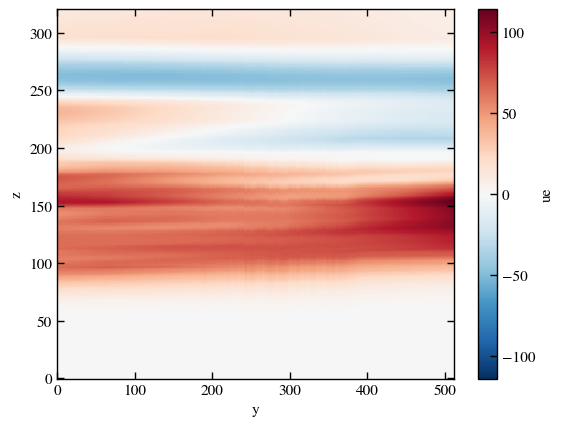

In [9]:
fpath = '/scratch/b/b309199/pata_2D'
ds, ds_xzslices, ds_yzslices, ds_xyslices, ds_lidars = plt_helper.preprocess_eulag_output(fpath)
ds_yzslices[0]['ue'][0].plot()

In [3]:
fpath = '/scratch/b/b309199/pata_tide'
ds, ds_env, ds_xzslices, ds_yzslices, ds_xyslices, ds_lidars, ds_full = plt_helper.preprocess_eulag_output(fpath)
ds

NameError: name 'plt_helper' is not defined

In [2]:
# fileLocation = '/work/bd0620/b309199/translb3D/translb3D_004'
fileLocation = '/scratch/b/b309199/pata0'
env_fileName   = "env.nc"
tapes_fileName = "tapes.nc" # "tapes.nc"
grid_fileName  = "grd.nc"
xyslc          = "xyslc.nc"
xzslc          = "xzslc.nc"

env_path   = os.path.join(fileLocation, env_fileName)
tapes_path = os.path.join(fileLocation, tapes_fileName)
grid_path  = os.path.join(fileLocation, grid_fileName)
xyslc      = os.path.join(fileLocation, xyslc)
xzslc      = os.path.join(fileLocation, xzslc)


ds = xr.open_dataset(xzslc)
ds_grd = xr.open_dataset(grid_path)
ds_env = xr.open_dataset(env_path)
ds

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/b/b309199/pata0/xzslc.nc'

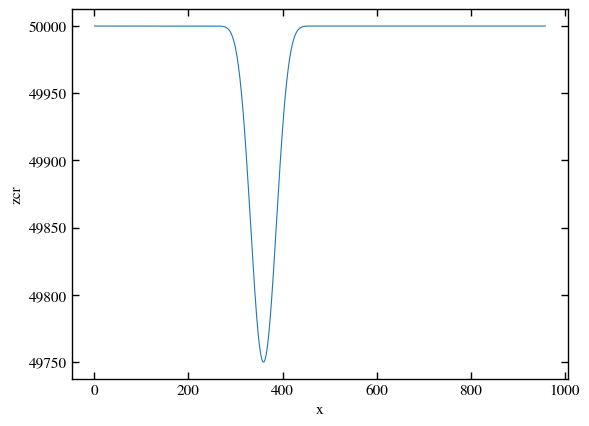

In [32]:
ds['zcr'][6,200,:].plot()

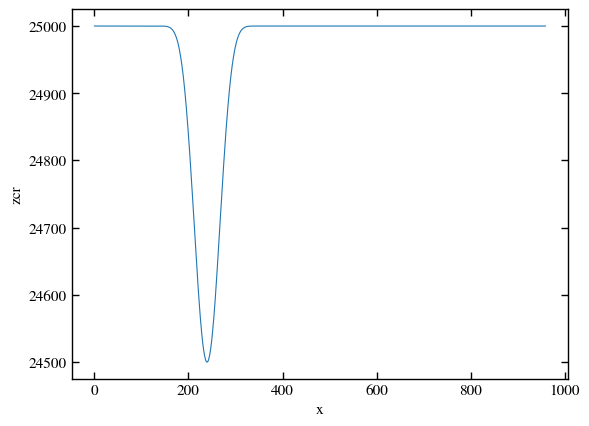

In [35]:
ds['zcr'][2,100,:].plot()